In [1]:
import os
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '..')))
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


In [2]:

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from src.data_handling.dataset_extended import ECGDataset
from src.data_handling.dataset import ECGAugmentation
from src.data_handling.dataset import stratified_subset, make_balanced_sampler, compute_alpha_from_weights,visualize_class_distributions

import torch
from src.model import (
    TransformerAutoencoder
)
import json
from torch.utils.data import DataLoader

In [3]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd()))
ROOT_DIR = os.path.join(BASE_DIR, '..')
DATA_DIR =  os.path.join(ROOT_DIR, 'Data')

In [4]:
y = np.array([0, 1, 0, 0, 0])
binary_y = np.zeros(2)
binary_y[int(y[1] == 1)] = 1 
binary_y

array([0., 1.])

In [5]:

with open(os.path.join(DATA_DIR, 'input', 'experiment', 'MLII_V1_strat_60_20_20_rd42.json'), 'r') as f:
        patient = json.load(f)

# Process each record
dict = {}
for rec_id in patient['train']:
    ann_file = os.path.join(DATA_DIR, 'mitbih_database', f"{rec_id}annotations.txt")
    ann_df = pd.read_csv(ann_file, sep='\s+', index_col=False, skiprows=1,
                         names=["Time", "Sample", "Type", "Sub", "Chan", "Num", "Aux"], quoting=3)


    dict[str(rec_id)] = ann_df['Aux'].unique().tolist()

ann_df['Aux_Filtered'] = ann_df['Aux']
ann_df.loc[~ann_df['Aux_Filtered'].astype(str).str.startswith('('), 'Aux_Filtered'] = np.nan
ann_df['Aux_Filled'] = ann_df['Aux_Filtered'].ffill()
print(dict)

{'106': [nan, '(N', '(B', '(VT', '(T'], '108': ['(N', nan], '111': ['(N', nan], '115': ['(N', nan], '118': ['(N', nan], '202': ['(N', nan, '(AFIB', '(AFL'], '203': ['(AFIB', nan, '(VT', '(T', '(AFL'], '208': ['(N', nan, '(T'], '209': ['(N', nan, '(SVTA'], '212': ['(N', nan], '213': ['(N', nan, '(B', '(VT'], '214': ['(N', nan, '(T', 'TS', '(VT'], '215': ['(N', nan, '(VT', 'TS'], '217': ['(P', nan, '(B', '(AFIB', '(VT'], '219': ['(AFIB', nan, '(T', 'PSE', '(N', 'MISSB', '(B'], '220': ['(N', nan, '(SVTA'], '222': ['(N', nan, '(AFIB', '(NOD', '(AFL', '(AB', '(SVTA'], '223': ['(N', nan, '(T', '(VT', '(B'], '228': ['(N', nan, '(B', 'TS'], '230': ['(N', nan, '(PREX'], '231': ['(N', nan, 'MISSB', '(BII'], '232': ['(SBR', nan], '233': ['(N', nan, '(VT', '(T', '(B'], '234': ['(N', nan, '(SVTA']}


In [6]:
# Create a boolean series: True where the label is different from the previous row.
label_change = ann_df['Aux_Filled'] != ann_df['Aux_Filled'].shift(1)

# Create the Group ID: Cumulatively sum the 'True' values.
# Each time a change happens (True), the ID increments.
ann_df['GroupID'] = label_change.cumsum()
# Group the data and apply multiple aggregation functions to the 'time' column
segment_timing = ann_df.groupby(['Aux_Filled', 'GroupID'])['Sample'].agg(
    # Get the time stamp of the first row in the segment
    Start_Time=('first'),
    # Get the time stamp of the last row in the segment
    End_Time=('last')
).reset_index()

# Calculate the duration by subtracting Start_Time from End_Time
segment_timing['Duration'] = segment_timing['End_Time'] - segment_timing['Start_Time']
print(segment_timing)

  Aux_Filled  GroupID  Start_Time  End_Time  Duration
0         (N        1          52    304312    304260
1         (N        3      313772    649772    336000
2      (SVTA        2      304425    313517      9092


In [11]:
data_dir = os.path.join(DATA_DIR, 'input', 'preprocessed_data',"fs250_bp0.5-45Hz_OneHot")
json_path = os.path.join(DATA_DIR, 'input', 'experiment', 'MLII_V1_strat_60_20_20_rd42.json')
# json_path = os.path.join(DATA_DIR, 'input', 'experiment', '1.json')

In [12]:

# --- Set up transform ---
transform = ECGAugmentation(preset='clsf')

Loading data for 24 patients from 'train' split...
Loading data for 24 patients from 'train' split...


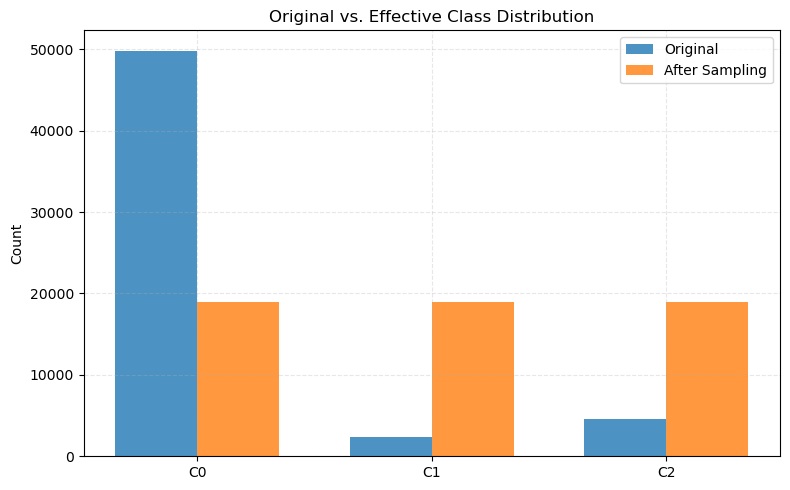

{'orig_counts': array([49827,  2397,  4547]),
 'eff_counts': array([18923.66666667, 18923.66666667, 18923.66666667]),
 'orig_probs': array([0.87768403, 0.04222226, 0.08009371]),
 'eff_probs': array([0.33333333, 0.33333333, 0.33333333])}

In [13]:
# --- Load dataset ---
dataset = ECGDataset(
    data_dir=data_dir,
    json_file_path=json_path,
    split="train",
    mode="clsf",
    window_size=256,
    transform=transform,
    important=True
)


dataset = ECGDataset(
    data_dir=data_dir,
    json_file_path=json_path,
    split="train",
    mode="clsf",
    window_size=256,
    important=True
)

# --- Pick one sample ---
# --- Pick one sample ---
# Use only 25% of training data (stratified)
train_dataset = stratified_subset(dataset, fraction=1.0)

# Balanced sampling
sampler, class_weights, class_counts = make_balanced_sampler(train_dataset)
a = visualize_class_distributions(dataset, sampler)
a


NameError: name 'dataset_no_aug' is not defined

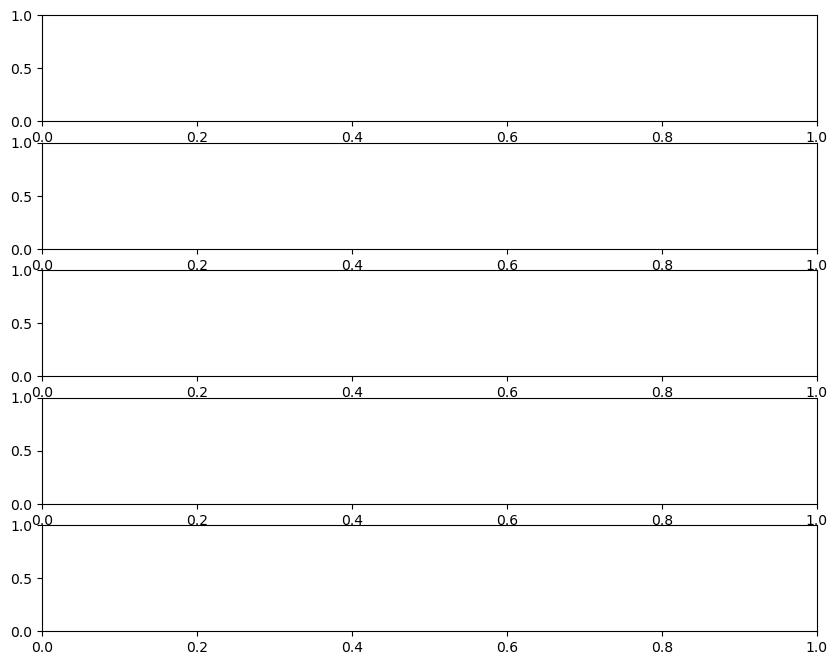

In [14]:
# --- Visualization ---
n_channels = 1
fig, ax = plt.subplots(5, figsize=(10,8))

for i in range(5):
    x_aug, label = dataset[i]
    x_orig, label = dataset_no_aug[i]
    ax[i].plot(x_orig[0].numpy(), label="Original", alpha=0.8)
    ax[i].plot(x_aug[0].numpy(), label="Augmented", alpha=0.8)
    ax[i].set_title(f"Label: {label}")
    ax[i].grid(True)

fig.suptitle(f"ECG Signal Augmentation ", fontsize=16)
plt.tight_layout()
plt.show()